## 1. Process Data to Define Trajectories

In [1]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

In [2]:
FIG_DIR = "figures/trajectory_mapping_game"
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
GAME_DATA_PATH = "umap_projections/game_vase_umap_projection.parquet"

In [4]:
df = pd.read_parquet(GAME_DATA_PATH)
df['generation'] = df['vase_id'].str.extract(r'(gen_\d+)').iloc[:, 0]
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,source,generation_key,vase,...,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,umap_x,umap_y,generation
0,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1
1,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1
2,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1
3,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1
4,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1


In [5]:
df.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'vase_id', 'source',
       'generation_key', 'vase', 'pc_name', 'pc_value', 'is_selected_vase',
       'is_parent_vase', 'selection_elapsed_time_s', 'decision_time_ms',
       'adjusted_selection_elapsed_time_s', 'adjusted_decision_time_ms',
       'rt_onset_correction_ms', 'rt_calibration_status',
       'rt_calibration_median_ms', 'rt_calibration_trials_n', 'participant_id',
       'session_id', 'play_counter', 'metadata_schema_version',
       'session_started_at', 'session_duration_s', 'completion_status',
       'umap_x', 'umap_y', 'generation'],
      dtype='str')

In [6]:
df['generation_num'] = df['generation'].str.extract(r'(\d+)').astype(int)
selected_by_generation = (
    df.loc[df['is_selected_vase'], ['participant_id', 'play_counter', 'generation_num', 'vase_id']]
      .rename(columns={'generation_num': 'parent_generation_num', 'vase_id': 'parent_vase_id'})
)
df['parent_generation_num'] = df['generation_num'] - 1
df = df.merge(
    selected_by_generation,
    on=['participant_id', 'play_counter', 'parent_generation_num'],
    how='left'
)
print(df.columns)
df.head()

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'vase_id', 'source',
       'generation_key', 'vase', 'pc_name', 'pc_value', 'is_selected_vase',
       'is_parent_vase', 'selection_elapsed_time_s', 'decision_time_ms',
       'adjusted_selection_elapsed_time_s', 'adjusted_decision_time_ms',
       'rt_onset_correction_ms', 'rt_calibration_status',
       'rt_calibration_median_ms', 'rt_calibration_trials_n', 'participant_id',
       'session_id', 'play_counter', 'metadata_schema_version',
       'session_started_at', 'session_duration_s', 'completion_status',
       'umap_x', 'umap_y', 'generation', 'generation_num',
       'parent_generation_num', 'parent_vase_id'],
      dtype='str')


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,source,generation_key,vase,...,metadata_schema_version,session_started_at,session_duration_s,completion_status,umap_x,umap_y,generation,generation_num,parent_generation_num,parent_vase_id
0,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN


In [7]:
trajectory_df = df[['participant_id', 'play_counter', 'generation_num', 'generation', 'vase_id', 'is_selected_vase', 'parent_vase_id', 'umap_x', 'umap_y']].copy()
trajectory_df = trajectory_df.sort_values(['participant_id', 'play_counter', 'generation_num', 'vase_id']).reset_index(drop=True)
trajectory_df.head(10)

,participant_id,play_counter,generation_num,generation,vase_id,is_selected_vase,parent_vase_id,umap_x,umap_y
0,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,False,NaN,4.898610,4.559932
1,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,False,NaN,4.898610,4.559932
2,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,False,NaN,4.898610,4.559932
3,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,False,NaN,4.898610,4.559932
4,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,False,NaN,4.898610,4.559932
5,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,False,NaN,4.898610,4.559932
6,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,True,NaN,7.006062,1.829477
7,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,True,NaN,7.006062,1.829477
8,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,True,NaN,7.006062,1.829477
9,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,1,gen_1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,True,NaN,7.006062,1.829477


In [8]:
# Create a DataFrame for trajectory edges (parent-child relationships)
trajectory_edges = trajectory_df.loc[trajectory_df['parent_vase_id'].notna(), ['participant_id', 'play_counter', 'parent_vase_id', 'vase_id', 'generation_num']].copy()
trajectory_edges = trajectory_edges.rename(columns={'vase_id': 'child_vase_id'})

trajectory_edges.head(10)

,participant_id,play_counter,parent_vase_id,child_vase_id,generation_num
12,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
13,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
14,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
15,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
16,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
17,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
18,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
19,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
20,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2
21,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2


In [9]:
# Create a mapping of parent_vase_id to list of child_vase_ids for each user and round
offspring_map = (
    trajectory_edges.groupby(['participant_id', 'play_counter', 'parent_vase_id'], as_index=False)['child_vase_id']
    .agg(list)
    .rename(columns={'child_vase_id': 'offspring_vase_ids'})
)

offspring_map.head(10)

,participant_id,play_counter,parent_vase_id,offspring_vase_ids
0,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_0...
1,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_0...
2,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_0...
3,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_0...
4,008e7cb7-6043-458b-870a-f3ec08d461e9,2.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_1_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_1...
5,008e7cb7-6043-458b-870a-f3ec08d461e9,2.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_1_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_1...
6,008e7cb7-6043-458b-870a-f3ec08d461e9,2.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_1_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_1...
7,008e7cb7-6043-458b-870a-f3ec08d461e9,2.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_1_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_1...
8,008e7cb7-6043-458b-870a-f3ec08d461e9,3.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_2_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_2...
9,008e7cb7-6043-458b-870a-f3ec08d461e9,3.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_2_...,[008e7cb7-6043-458b-870a-f3ec08d461e9::round_2...


In [10]:
# GPT4_DATA_PATH = "umap_projections/gpt4_vase_umap_projection.parquet"

# gpt4_df = pd.read_parquet(GPT4_DATA_PATH)

# # Parse user_id and round from vase_id format: {uuid}_vase_{round}_{index}
# _parsed = gpt4_df['vase_id'].str.extract(
#     r'^([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})_vase_(\d+)_'
# )
# gpt4_df['user_id'] = _parsed[0]
# gpt4_df['round']   = _parsed[1].astype('Int64')

# print(f"GPT4 vases: {len(gpt4_df):,}")
# gpt4_df.head()

In [11]:
# # Build GPT4 transition pairs: within each (user_id, round) batch,
# # pair every non-selected vase with the one the user selected.
# # This treats each selection as a "pull" toward the chosen vase.
# gpt4_selected = (
#     gpt4_df[gpt4_df['is_selected'] == True][['user_id', 'round', 'vase_id', 'umap_x', 'umap_y']]
#     .rename(columns={'vase_id': 'selected_vase_id',
#                      'umap_x': 'child_umap_x', 'umap_y': 'child_umap_y'})
# )
# gpt4_pairs = (
#     gpt4_df
#     .merge(gpt4_selected, on=['user_id', 'round'], how='inner')
#     .query('vase_id != selected_vase_id')
#     .rename(columns={'umap_x': 'parent_umap_x', 'umap_y': 'parent_umap_y'})
#     .dropna(subset=['parent_umap_x', 'parent_umap_y', 'child_umap_x', 'child_umap_y'])
#     .copy()
# )
# print(f"GPT4 transition pairs: {len(gpt4_pairs):,}")
# gpt4_pairs[['user_id', 'round', 'vase_id', 'parent_umap_x', 'parent_umap_y', 'child_umap_x', 'child_umap_y']].head()

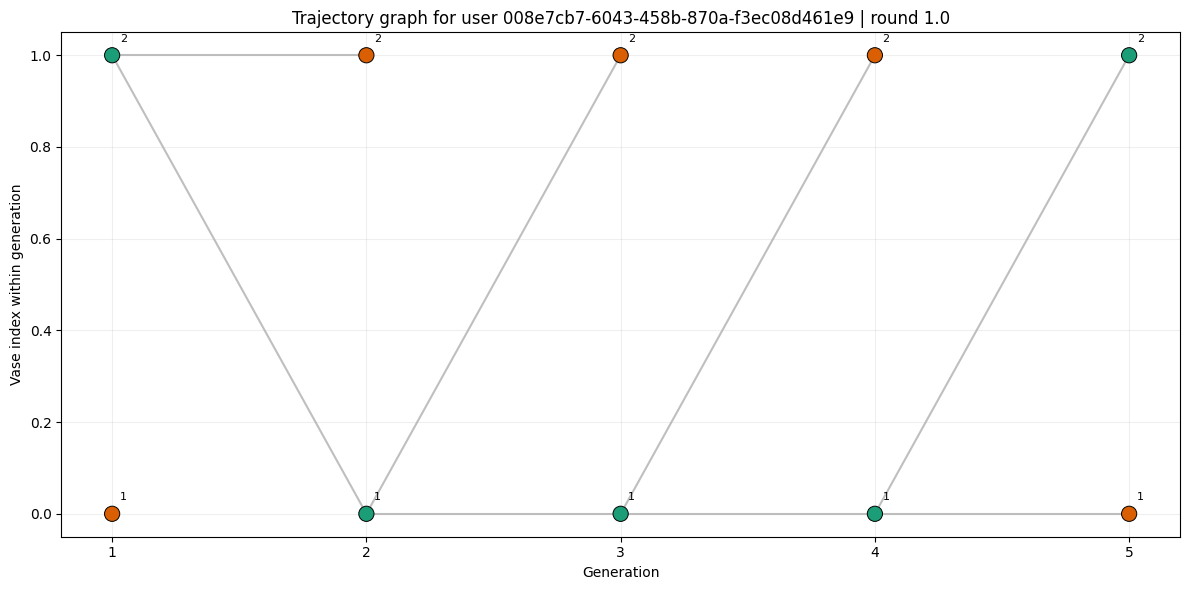

In [12]:
selected_user_id = trajectory_df['participant_id'].iloc[0]
selected_round = trajectory_df['play_counter'].iloc[0]

plot_df = (
    trajectory_df[
        (trajectory_df['participant_id'] == selected_user_id) &
        (trajectory_df['play_counter'] == selected_round)
    ]
    .drop_duplicates('vase_id')
    .copy()
)
plot_edges = trajectory_edges[
    (trajectory_edges['participant_id'] == selected_user_id) &
    (trajectory_edges['play_counter'] == selected_round)
].drop_duplicates(['parent_vase_id', 'child_vase_id']).copy()

plot_df['generation_label'] = plot_df['generation_num'].map(lambda n: f'Gen {n}')
plot_df['y_plot'] = plot_df.groupby('generation_num').cumcount()
positions = plot_df.set_index('vase_id')[['generation_num', 'y_plot']].to_dict('index')

fig, ax = plt.subplots(figsize=(12, 6))
for _, edge in plot_edges.iterrows():
    parent_pos = positions.get(edge['parent_vase_id'])
    child_pos = positions.get(edge['child_vase_id'])
    if parent_pos is None or child_pos is None:
        continue
    ax.plot(
        [parent_pos['generation_num'], child_pos['generation_num']],
        [parent_pos['y_plot'], child_pos['y_plot']],
        color='0.75', linewidth=1.5, zorder=1
    )

ax.scatter(
    plot_df['generation_num'],
    plot_df['y_plot'],
    s=120, c=plot_df['is_selected_vase'].map({False: '#d95f02', True: '#1b9e77'}),
    edgecolors='black', linewidths=0.7, zorder=2
)

for _, row in plot_df.iterrows():
    ax.text(row['generation_num'] + 0.03, row['y_plot'] + 0.03, row['vase_id'].split('_')[-1], fontsize=8)

ax.set_title(f'Trajectory graph for user {selected_user_id} | round {selected_round}')
ax.set_xlabel('Generation')
ax.set_ylabel('Vase index within generation')
ax.set_xticks(sorted(plot_df['generation_num'].unique()))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Build the Latent Space Trajectory Map

In [13]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

In [14]:
COMBINED_UMAP_PATH = "umap_projections/combined_vase_umap_projection.parquet"
_bounds = pd.read_parquet(COMBINED_UMAP_PATH, columns=['umap_x', 'umap_y'])
UMAP_X_MIN, UMAP_X_MAX = _bounds['umap_x'].min(), _bounds['umap_x'].max()
UMAP_Y_MIN, UMAP_Y_MAX = _bounds['umap_y'].min(), _bounds['umap_y'].max()
del _bounds
UMAP_PAD_X = (UMAP_X_MAX - UMAP_X_MIN) * 0.02
UMAP_PAD_Y = (UMAP_Y_MAX - UMAP_Y_MIN) * 0.02
UMAP_XLIM = (UMAP_X_MIN - UMAP_PAD_X, UMAP_X_MAX + UMAP_PAD_X)
UMAP_YLIM = (UMAP_Y_MIN - UMAP_PAD_Y, UMAP_Y_MAX + UMAP_PAD_Y)
print(f"Shared UMAP bounds — x: {UMAP_XLIM[0]:.3f} → {UMAP_XLIM[1]:.3f} | y: {UMAP_YLIM[0]:.3f} → {UMAP_YLIM[1]:.3f}")

Shared UMAP bounds — x: -6.498 → 16.848 | y: -1.828 → 11.462


In [15]:
# Build a deduplicated vase_id → UMAP lookup (trajectory_df is long-format, one row per PC)
vase_umap = (
    trajectory_df[['vase_id', 'umap_x', 'umap_y']]
    .drop_duplicates('vase_id')
    .set_index('vase_id')
)

# Map parent and child coordinates directly — vase_id is globally unique so no 3-key merge needed
trajectory_pairs = trajectory_edges.copy()
trajectory_pairs['parent_umap_x'] = trajectory_pairs['parent_vase_id'].map(vase_umap['umap_x'])
trajectory_pairs['parent_umap_y'] = trajectory_pairs['parent_vase_id'].map(vase_umap['umap_y'])
trajectory_pairs['child_umap_x']  = trajectory_pairs['child_vase_id'].map(vase_umap['umap_x'])
trajectory_pairs['child_umap_y']  = trajectory_pairs['child_vase_id'].map(vase_umap['umap_y'])

trajectory_pairs.head()

,participant_id,play_counter,parent_vase_id,child_vase_id,generation_num,parent_umap_x,parent_umap_y,child_umap_x,child_umap_y
12,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2,7.006062,1.829477,7.000542,1.829155
13,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2,7.006062,1.829477,7.000542,1.829155
14,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2,7.006062,1.829477,7.000542,1.829155
15,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2,7.006062,1.829477,7.000542,1.829155
16,008e7cb7-6043-458b-870a-f3ec08d461e9,1.0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2,7.006062,1.829477,7.000542,1.829155


In [16]:
# Remove pairs where UMAP coords are missing
trajectory_pairs = trajectory_pairs.dropna(
    subset=['parent_umap_x', 'parent_umap_y', 'child_umap_x', 'child_umap_y']
).copy()

# Keep a named copy for the permutation test later
game_transition_pairs = trajectory_pairs[
    ['parent_umap_x', 'parent_umap_y', 'child_umap_x', 'child_umap_y']
].copy()

Z       = game_transition_pairs[['parent_umap_x', 'parent_umap_y']].to_numpy().T
Z_prime = game_transition_pairs[['child_umap_x',  'child_umap_y' ]].to_numpy().T

if Z.shape[1] == 0:
    raise ValueError('Zero trajectories extracted. Check the parent/child lineage logic.')

print(f'Game transition pairs: {Z.shape[1]:,}')
print(f'Missing pairs removed: {trajectory_edges.shape[0] - trajectory_pairs.shape[0]}')

Game transition pairs: 1,438,560
Missing pairs removed: 0


In [17]:
N_GRID = 30 # The number of grid points along each dimension for the RBF centers (NxN landmark points)
x_min, x_max = UMAP_X_MIN, UMAP_X_MAX
y_min, y_max = UMAP_Y_MIN, UMAP_Y_MAX
grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, N_GRID), np.linspace(y_min, y_max, N_GRID))
centres = np.vstack([grid_x.ravel(), grid_y.ravel()]).T # Shape (N_GRID^2, 2) - each row is the (x,y) coordinates of an RBF center

In [18]:
nn = NearestNeighbors(n_neighbors=2).fit(centres)
distances, _ = nn.kneighbors(centres)
SIGMA = np.median(distances[:, 1])
print(f"Data determined sigma: {SIGMA:.4f}")

Data determined sigma: 0.4406


In [19]:
def lift_to_observables(z_data, centres, sigma):
    ''' 
    Lift 2D UMAP coordinates to a higher-dimensional space of RBF observables.
    z_data: shape (2, num_samples) - columns are (x,y) coordinates
    centres: shape (num_centres, 2) - rows are (x,y) coordinates of RBF centers
    sigma: width parameter for the RBFs
    returns: shape (num_centres, num_samples) - each column is the RBF feature vector for the corresponding column in z_data
    '''
    points = z_data.T
    distances = np.sum((points[:, None, :] - centres[None, :, :]) ** 2, axis=2)
    return np.exp(-distances / (2 * sigma ** 2)).T

In [20]:
CHUNK_SIZE = 10_000  # rows processed at a time — tune up if RAM allows
n_rbf = len(centres)
n_trans = Z.shape[1]

A = np.zeros((n_rbf, n_rbf))   # Psi_Z  @ Psi_Z.T  — (900, 900)
B = np.zeros((n_rbf, n_rbf))   # Psi_Z' @ Psi_Z.T  — (900, 900)

for start in tqdm(range(0, n_trans, CHUNK_SIZE), desc="Building Koopman Gram matrices"):
    sl = slice(start, start + CHUNK_SIZE)
    psi   = lift_to_observables(Z[:, sl],       centres, SIGMA)  # (900, chunk)
    psi_p = lift_to_observables(Z_prime[:, sl], centres, SIGMA)  # (900, chunk)
    A += psi   @ psi.T
    B += psi_p @ psi.T

# K A = B  ->  solve for K via K = B @ inv(A) = solve(A.T, B.T).T
K = np.linalg.solve(A.T, B.T).T

Building Koopman Gram matrices: 100%|██████████| 144/144 [00:21<00:00,  6.69it/s]


In [21]:
# Check whether gravity should be flipped by testing correlation with selection.
# Eigen decomposition from Koopman matrix
evals_raw, evecs_raw = np.linalg.eig(K)

In [22]:
# Evaluate eigenfunction on each vase position for both orientations
# df is long-format so we compute gravity in chunks to avoid a (900 x 1.5M) matrix
idx_no_flip = np.argmin(np.abs(evals_raw - 1.0))
dom_no_flip = np.real(evecs_raw[:, idx_no_flip])

vase_xy = np.vstack([df["umap_x"].to_numpy(), df["umap_y"].to_numpy()])  # (2, N)
n_vases = vase_xy.shape[1]

gravity_no_flip = np.empty(n_vases)
gravity_flip    = np.empty(n_vases)

for start in range(0, n_vases, CHUNK_SIZE):
    sl = slice(start, start + CHUNK_SIZE)
    psi_chunk = lift_to_observables(vase_xy[:, sl], centres, SIGMA)  # (900, chunk)
    gravity_no_flip[sl] = (dom_no_flip @ psi_chunk).real
    gravity_flip[sl]    = (-dom_no_flip @ psi_chunk).real


In [23]:
# Build vase-level table: selection rate per vase vs gravity score
check = df[["vase_id", "is_selected_vase"]].copy()
check["selected"] = check["is_selected_vase"].astype(float)
check["gravity_no_flip"] = gravity_no_flip
check["gravity_flip"] = gravity_flip

In [24]:
vase_check = (
    check.groupby("vase_id", as_index=False)
    .agg(
        selected_rate=("selected", "mean"),
        gravity_no_flip=("gravity_no_flip", "mean"),
        gravity_flip=("gravity_flip", "mean"),
    )
    .dropna(subset=["selected_rate", "gravity_no_flip", "gravity_flip"])
)
vase_check.head()

,vase_id,selected_rate,gravity_no_flip,gravity_flip
0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,0.0,0.028330,-0.028330
1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,1.0,0.018917,-0.018917
2,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,1.0,0.019193,-0.019193
3,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,0.0,0.220625,-0.220625
4,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,1.0,0.019008,-0.019008


In [25]:
# Correlations (Pearson + Spearman)
pearson_no_flip = vase_check["gravity_no_flip"].corr(vase_check["selected_rate"], method="pearson")
pearson_flip = vase_check["gravity_flip"].corr(vase_check["selected_rate"], method="pearson")
spearman_no_flip = vase_check["gravity_no_flip"].corr(vase_check["selected_rate"], method="spearman")
spearman_flip = vase_check["gravity_flip"].corr(vase_check["selected_rate"], method="spearman")

print(f"Pearson  (no flip): {pearson_no_flip:.6f}")
print(f"Pearson  (flip)   : {pearson_flip:.6f}")
print(f"Spearman (no flip): {spearman_no_flip:.6f}")
print(f"Spearman (flip)   : {spearman_flip:.6f}")

if np.isnan(pearson_no_flip) or np.isnan(pearson_flip):
    print("Could not decide automatically (NaN correlation).")
else:
    preferred = "flip" if pearson_flip > pearson_no_flip else "no flip"
    print(f"Preferred orientation by Pearson: {preferred}")

Pearson  (no flip): 0.026694
Pearson  (flip)   : -0.026694
Spearman (no flip): 0.036118
Spearman (flip)   : -0.036118
Preferred orientation by Pearson: no flip


In [26]:
if pearson_flip > pearson_no_flip:
    print("Flipping gravity orientation based on higher Pearson correlation with selection.")
    eigenvalues = evals_flip
    eigenvectors = evecs_flip
else:
    print("Keeping original gravity orientation based on higher Pearson correlation with selection.")
    eigenvalues = evals_raw
    eigenvectors = evecs_raw

Keeping original gravity orientation based on higher Pearson correlation with selection.


In [27]:
idx_attractor = np.argmin(np.abs(eigenvalues - 1.0))
dominant_eigenvector = np.real(eigenvectors[:, idx_attractor])  # Shape: (N_rbf,)

# Store game-specific copies for later comparison
game_dominant_eigenvector = dominant_eigenvector.copy()

In [28]:
dense_points = np.vstack([grid_x.ravel(), grid_y.ravel()])  # (2, N_GRID^2)
Psi_grid = lift_to_observables(dense_points, centres, SIGMA)  # (num_centres, N_GRID^2)
phi_1 = dominant_eigenvector @ Psi_grid                        # (N_GRID^2,)
phi_1_2D = phi_1.reshape(grid_x.shape)                        # (N_GRID, N_GRID)
V, U = np.gradient(phi_1_2D)

# Store game-specific grid for comparison
game_phi_1_2D = phi_1_2D.copy()
game_U, game_V = U.copy(), V.copy()

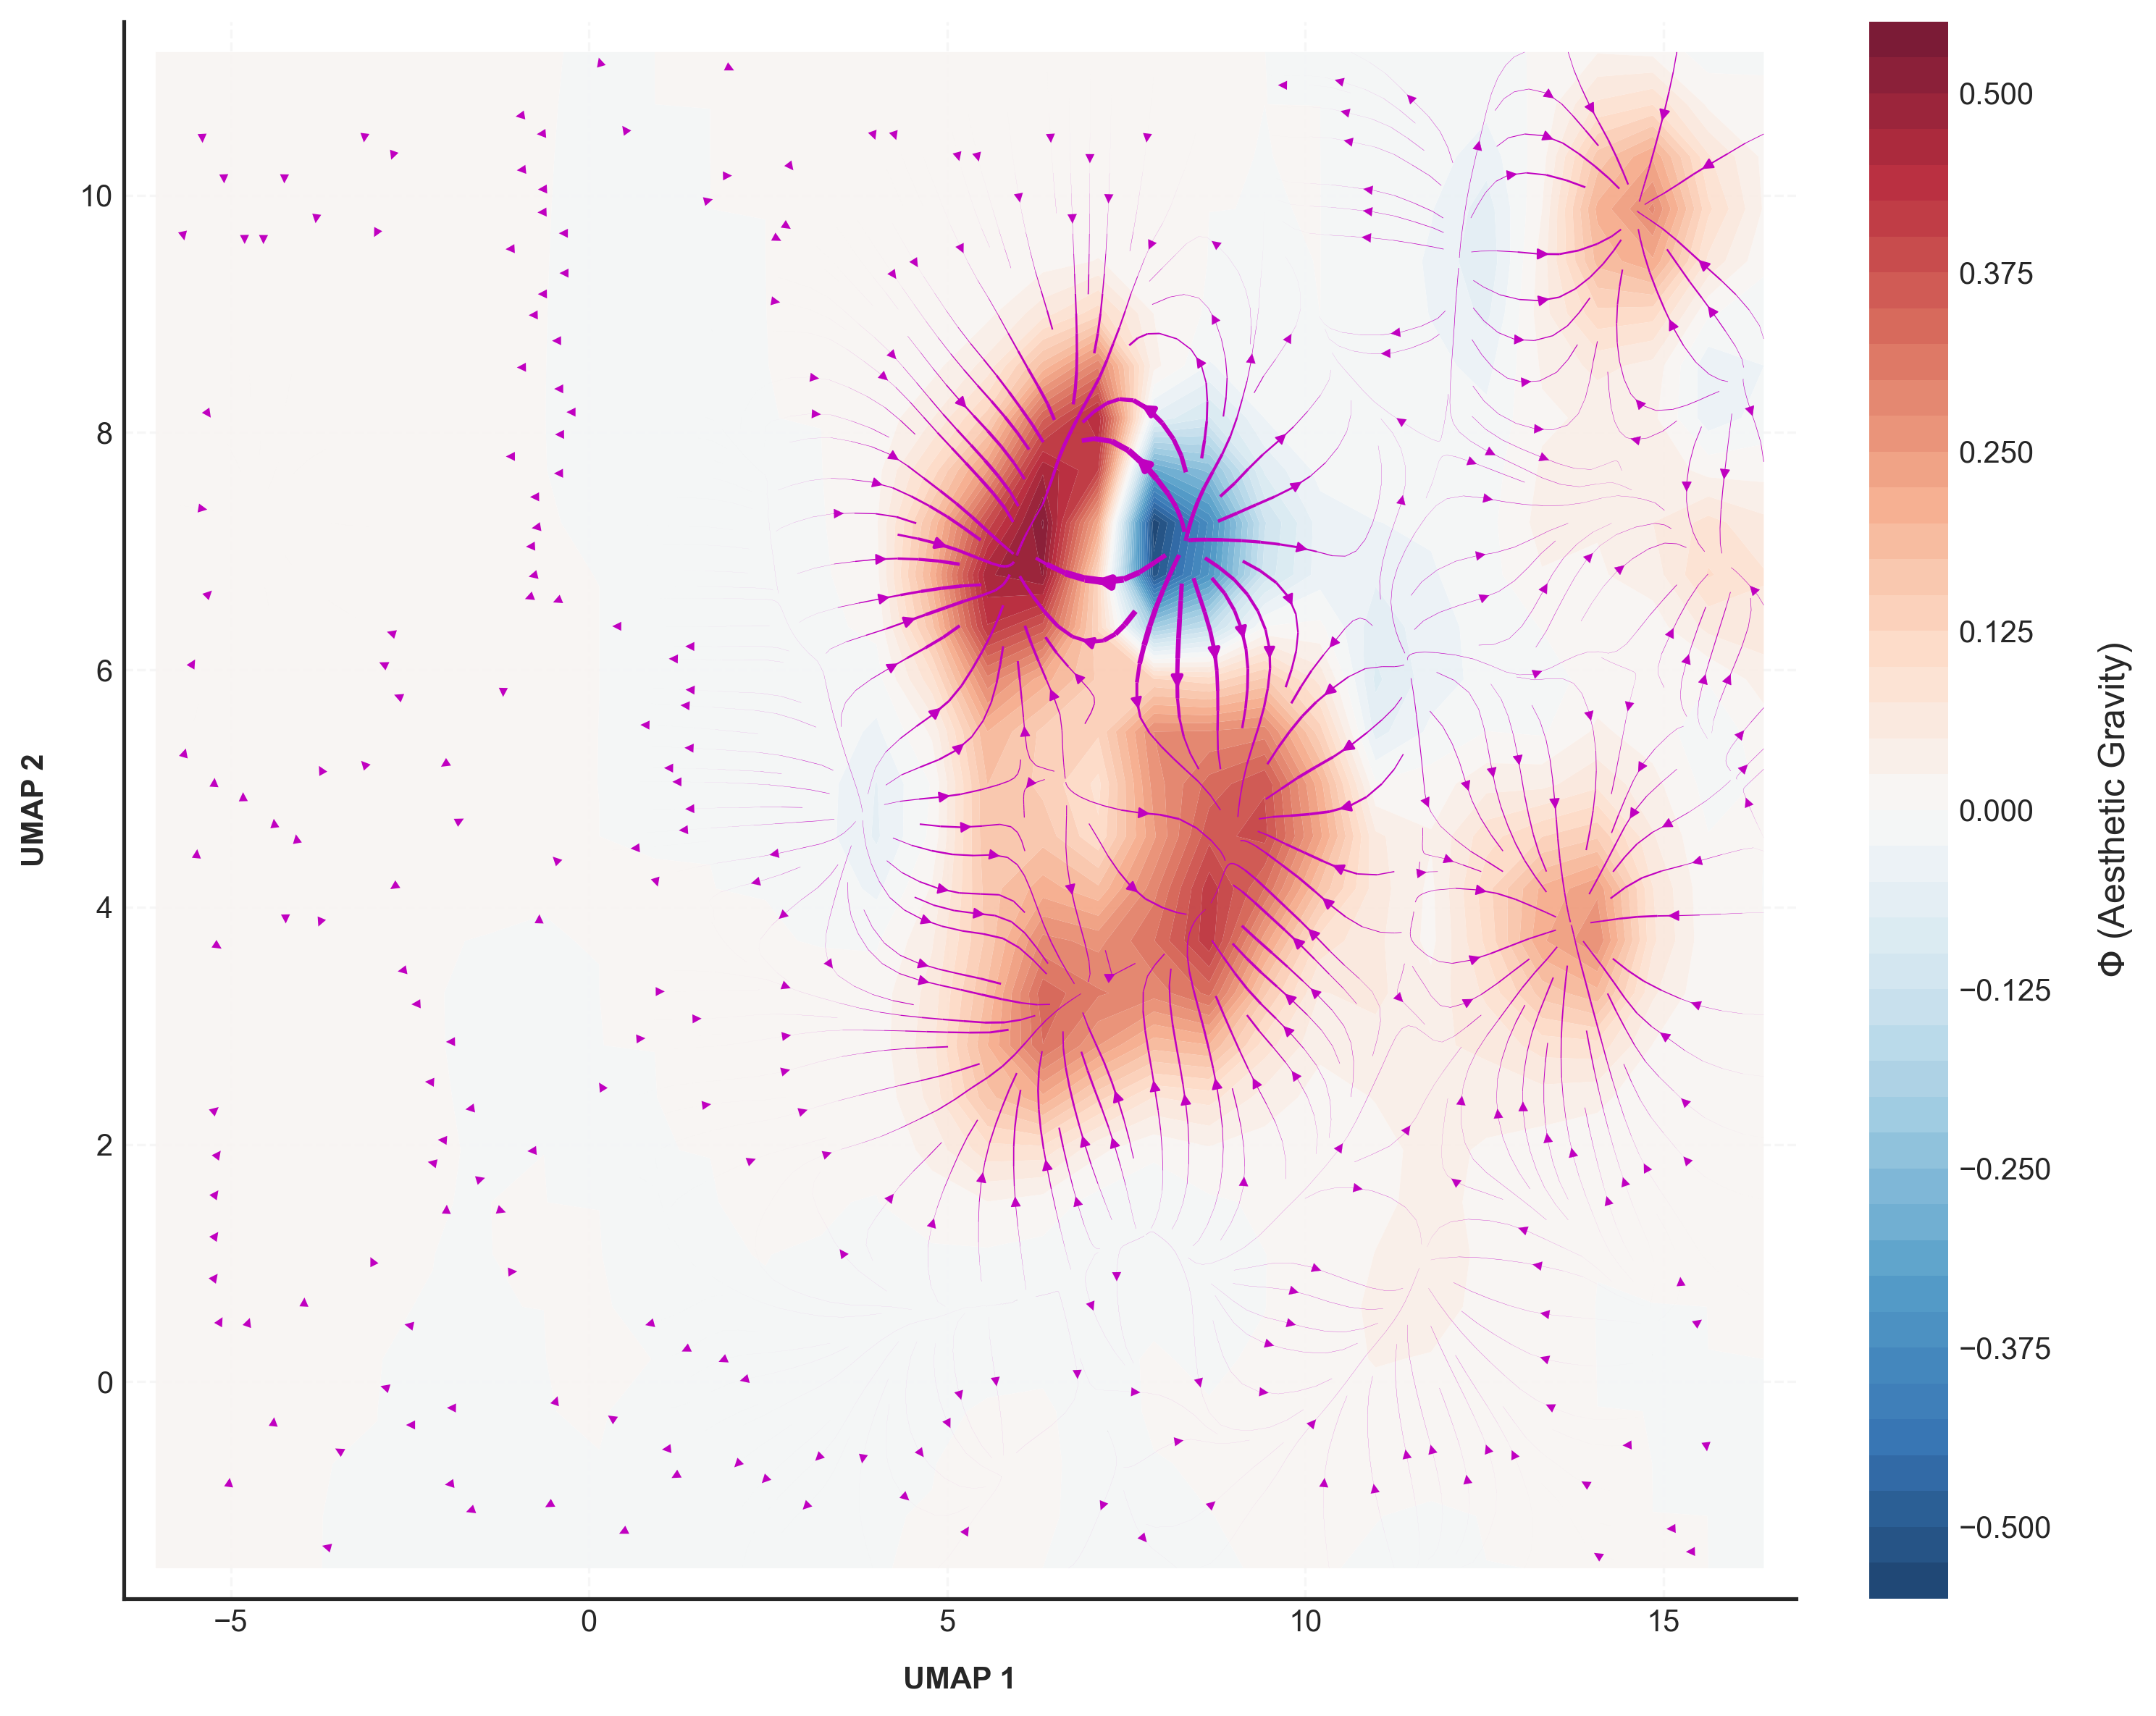

In [29]:
plt.style.use('seaborn-v0_8-white')

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
heatmap = ax.contourf(grid_x, grid_y, phi_1_2D, levels=50, 
                      cmap='RdBu_r', alpha=0.9, antialiased=True)
cbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label(r'$\Phi$ (Aesthetic Gravity)', fontsize=12, labelpad=15)

arrow_color = "#C000C0"
speed = np.sqrt(U ** 2 + V ** 2)
linewidth = 3 * speed / (speed.max() + 1e-9)
ax.streamplot(grid_x, grid_y, U, V, color=arrow_color, 
              linewidth=linewidth, density=2.5, arrowstyle='-|>', arrowsize=0.75)

ax.set_xlim(*UMAP_XLIM)
ax.set_ylim(*UMAP_YLIM)
ax.set_xlabel('UMAP 1', fontweight='bold', labelpad=10)
ax.set_ylabel('UMAP 2', fontweight='bold', labelpad=10)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', color='#EEEEEE', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/vase_gravity_map.svg', dpi=600)
plt.show()

## 2b. GPT4 Gravity Field

In [30]:
# # Build GPT4 Koopman operator from non-selected → selected transition pairs
# Z_gpt4       = gpt4_pairs[['parent_umap_x', 'parent_umap_y']].to_numpy().T
# Z_prime_gpt4 = gpt4_pairs[['child_umap_x',  'child_umap_y' ]].to_numpy().T

# Psi_Z_gpt4       = lift_to_observables(Z_gpt4,       centres, SIGMA)
# Psi_Z_prime_gpt4 = lift_to_observables(Z_prime_gpt4, centres, SIGMA)
# K_gpt4 = Psi_Z_prime_gpt4 @ np.linalg.pinv(Psi_Z_gpt4)

# evals_gpt4, evecs_gpt4 = np.linalg.eig(K_gpt4)
# print(f"GPT4 transition pairs used: {Z_gpt4.shape[1]:,}")

In [31]:
# # Orientation check for GPT4: choose sign that correlates positively with selection rate
# vase_points_gpt4 = np.vstack([gpt4_df['umap_x'].to_numpy(), gpt4_df['umap_y'].to_numpy()])
# Psi_vases_gpt4   = lift_to_observables(vase_points_gpt4, centres, SIGMA)

# idx_no_flip_g4 = np.argmin(np.abs(evals_gpt4 - 1.0))
# dom_no_flip_g4 = np.real(evecs_gpt4[:, idx_no_flip_g4])
# gravity_no_flip_g4 = (dom_no_flip_g4 @ Psi_vases_gpt4).real
# gravity_flip_g4    = -gravity_no_flip_g4

# check_g4 = gpt4_df[['vase_id', 'is_selected']].copy()
# check_g4['selected']       = check_g4['is_selected'].astype(float)
# check_g4['gravity_no_flip'] = gravity_no_flip_g4
# check_g4['gravity_flip']    = gravity_flip_g4

# vase_check_g4 = (
#     check_g4.groupby('vase_id', as_index=False)
#     .agg(selected_rate=('selected', 'mean'),
#          gravity_no_flip=('gravity_no_flip', 'mean'),
#          gravity_flip=('gravity_flip', 'mean'))
#     .dropna()
# )
# pearson_no_flip_g4 = vase_check_g4['gravity_no_flip'].corr(vase_check_g4['selected_rate'])
# pearson_flip_g4    = vase_check_g4['gravity_flip'].corr(vase_check_g4['selected_rate'])
# print(f"GPT4 Pearson (no flip): {pearson_no_flip_g4:.4f}  |  (flip): {pearson_flip_g4:.4f}")

# if pearson_flip_g4 > pearson_no_flip_g4:
#     print("Flipping GPT4 orientation.")
#     gpt4_dominant_eigenvector = -dom_no_flip_g4
# else:
#     print("Keeping original GPT4 orientation.")
#     gpt4_dominant_eigenvector = dom_no_flip_g4

In [32]:
# # Evaluate GPT4 gravity field on the shared grid
# phi_1_gpt4 = gpt4_dominant_eigenvector @ Psi_grid  # Psi_grid already built on same grid
# gpt4_phi_1_2D = phi_1_gpt4.reshape(grid_x.shape)
# gpt4_V, gpt4_U = np.gradient(gpt4_phi_1_2D)

In [33]:
# # GPT4 stream plot
# fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
# heatmap = ax.contourf(grid_x, grid_y, gpt4_phi_1_2D, levels=50,
#                       cmap='RdBu_r', alpha=0.9, antialiased=True)
# cbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
# cbar.outline.set_visible(False)
# cbar.set_label(r'$\Phi$ (Aesthetic Gravity — GPT4)', fontsize=12, labelpad=15)

# speed_g4  = np.sqrt(gpt4_U ** 2 + gpt4_V ** 2)
# lw_g4     = 3 * speed_g4 / (speed_g4.max() + 1e-9)
# ax.streamplot(grid_x, grid_y, gpt4_U, gpt4_V, color='#C000C0',
#               linewidth=lw_g4, density=2.5, arrowstyle='-|>', arrowsize=0.75)

# ax.set_xlim(*UMAP_XLIM); ax.set_ylim(*UMAP_YLIM)
# ax.set_xlabel('UMAP 1', fontweight='bold', labelpad=10)
# ax.set_ylabel('UMAP 2', fontweight='bold', labelpad=10)
# ax.set_title('GPT4 Aesthetic Gravity Field', fontsize=14)
# ax.spines[['top', 'right']].set_visible(False)
# ax.grid(True, linestyle='--', color='#EEEEEE', alpha=0.5)
# plt.tight_layout()
# plt.savefig(f'{FIG_DIR}/gpt4_gravity_map.svg', dpi=600)
# plt.show()

In [34]:
# # Side-by-side comparison of game vs GPT4 gravity fields
# fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=200)

# # Shared colour scale so both panels are comparable
# phi_all = np.concatenate([game_phi_1_2D.ravel(), gpt4_phi_1_2D.ravel()])
# vmin, vmax = np.percentile(phi_all, [2, 98])

# for ax, phi_2D, U_arr, V_arr, title in [
#     (axes[0], game_phi_1_2D, game_U, game_V,  'Game'),
#     (axes[1], gpt4_phi_1_2D, gpt4_U, gpt4_V, 'GPT4'),
# ]:
#     cf = ax.contourf(grid_x, grid_y, phi_2D, levels=50, cmap='RdBu_r',
#                      vmin=vmin, vmax=vmax, alpha=0.9, antialiased=True)
#     fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
#     speed = np.sqrt(U_arr**2 + V_arr**2)
#     lw = 2.5 * speed / (speed.max() + 1e-9)
#     ax.streamplot(grid_x, grid_y, U_arr, V_arr, color='#C000C0',
#                   linewidth=lw, density=2.0, arrowstyle='-|>', arrowsize=0.75)
#     ax.set_xlim(*UMAP_XLIM); ax.set_ylim(*UMAP_YLIM)
#     ax.set_aspect('equal')
#     ax.set_title(f'{title} Aesthetic Gravity Field', fontsize=13)
#     ax.set_xlabel('UMAP 1', fontweight='bold')
#     ax.set_ylabel('UMAP 2', fontweight='bold')
#     ax.spines[['top', 'right']].set_visible(False)

# plt.suptitle('Gravity Field Comparison: Game vs GPT4', fontsize=15, y=1.01)
# plt.tight_layout()
# plt.savefig(f'{FIG_DIR}/gravity_comparison.svg', dpi=300)
# plt.show()

## 2c. Permutation Test: Are the Game and GPT4 Gravity Fields Significantly Similar?

**Null hypothesis**: the similarity between the two fields is no greater than would arise if we randomly split the pooled transitions into two groups of the same sizes.

For each permutation we pool all transitions, randomly assign them to a "game" and "gpt4" split, rebuild both Koopman operators, compute each φ on the grid, and record the Pearson correlation between the two φ fields. The observed correlation is then compared against this null distribution.

In [ ]:
# from scipy.stats import pearsonr, spearmanr

# def _koopman_phi(parent_xy, child_xy, centres, sigma, Psi_grid, chunk_size=10_000):
#     """Build Koopman K from transition pairs and return the leading eigenfunction on Psi_grid."""
#     n_rbf = len(centres)
#     n = parent_xy.shape[0]
#     A = np.zeros((n_rbf, n_rbf))
#     B = np.zeros((n_rbf, n_rbf))
#     Z  = parent_xy.T
#     Zp = child_xy.T
#     for start in range(0, n, chunk_size):
#         sl = slice(start, start + chunk_size)
#         psi  = lift_to_observables(Z[:, sl],  centres, sigma)
#         psip = lift_to_observables(Zp[:, sl], centres, sigma)
#         A += psi  @ psi.T
#         B += psip @ psi.T
#     K = np.linalg.solve(A.T, B.T).T
#     evals, evecs = np.linalg.eig(K)
#     idx = np.argmin(np.abs(evals - 1.0))
#     phi = (np.real(evecs[:, idx]) @ Psi_grid).real
#     return phi

# # Observed similarity
# obs_r, obs_p = pearsonr(game_phi_1_2D.ravel(), gpt4_phi_1_2D.ravel())
# print(f"Observed Pearson r between game and GPT4 gravity fields: {obs_r:+.4f}  (p={obs_p:.3e})")
# # Use absolute value: we do not know which sign convention each permutation will land on
# obs_r_abs = abs(obs_r)


NameError: name 'gpt4_phi_1_2D' is not defined

In [ ]:
N_PERM = 100
rng    = np.random.default_rng(42)

# Pool all transitions into a single array [parent_x, parent_y, child_x, child_y]
game_arr = game_transition_pairs[['parent_umap_x', 'parent_umap_y', 'child_umap_x', 'child_umap_y']].to_numpy()
gpt4_arr = gpt4_pairs[         ['parent_umap_x', 'parent_umap_y', 'child_umap_x', 'child_umap_y']].to_numpy()

pooled   = np.vstack([game_arr, gpt4_arr])
n_game   = len(game_arr)
n_total  = len(pooled)

null_rs = np.empty(N_PERM)

for i in tqdm(range(N_PERM), desc='Permutations'):
    idx = rng.permutation(n_total)
    split_a = pooled[idx[:n_game]]
    split_b = pooled[idx[n_game:]]

    phi_a = _koopman_phi(split_a[:, :2], split_a[:, 2:], centres, SIGMA, Psi_grid)
    phi_b = _koopman_phi(split_b[:, :2], split_b[:, 2:], centres, SIGMA, Psi_grid)

    r, _ = pearsonr(phi_a, phi_b)
    null_rs[i] = abs(r)

p_value = (null_rs >= obs_r_abs).mean()
print(f"\nPermutation test (n={N_PERM}):")
print(f"  Observed |r| = {obs_r_abs:.4f}")
print(f"  Null mean    = {null_rs.mean():.4f}  ± {null_rs.std():.4f}")
print(f"  p-value      = {p_value:.4f}  ({'significant' if p_value < 0.05 else 'not significant'} at α=0.05)")

In [ ]:
# Plot the null distribution vs observed statistic
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.hist(null_rs, bins=40, color='#4a90d9', edgecolor='white', linewidth=0.5,
        alpha=0.85, label='Null distribution (|r| under random split)')
ax.axvline(obs_r_abs, color='#e74c3c', linewidth=2.5,
           label=f'Observed |r| = {obs_r_abs:.3f}  (p = {p_value:.3f})')
ax.set_xlabel('|Pearson r| between gravity fields', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Permutation test: Game vs GPT4 gravity field similarity', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/permutation_test.svg', dpi=300)
plt.show()

In [39]:
# ── Selected (parent → child) transitions only ──────────────────────────────
_sel_info = (
    trajectory_df[['participant_id', 'play_counter', 'vase_id', 'is_selected_vase']]
    .rename(columns={'vase_id': 'child_vase_id'})
)
sel_pairs = (
    trajectory_pairs
    .merge(_sel_info, on=['participant_id', 'play_counter', 'child_vase_id'], how='left')
    .query('is_selected_vase == True')
    .copy()
)
del _sel_info

# Direction of each selection step in UMAP space
sel_pairs['dx'] = sel_pairs['child_umap_x'] - sel_pairs['parent_umap_x']
sel_pairs['dy'] = sel_pairs['child_umap_y'] - sel_pairs['parent_umap_y']
sel_pairs['theta'] = np.arctan2(sel_pairs['dy'], sel_pairs['dx'])

print(f"Selected transitions: {len(sel_pairs):,}")

# ── Assign each parent to the 30×30 Koopman grid ────────────────────────────
N_DIR_BINS = 8          # 8 compass directions
MIN_COUNT  = 5          # cells with fewer transitions → NaN
H_MAX = np.log(N_DIR_BINS)

x_ent_edges = np.linspace(UMAP_X_MIN, UMAP_X_MAX, N_GRID + 1)
y_ent_edges = np.linspace(UMAP_Y_MIN, UMAP_Y_MAX, N_GRID + 1)

sel_pairs['grid_ix'] = np.clip(
    np.searchsorted(x_ent_edges, sel_pairs['parent_umap_x'].to_numpy(), side='right') - 1,
    0, N_GRID - 1
)
sel_pairs['grid_iy'] = np.clip(
    np.searchsorted(y_ent_edges, sel_pairs['parent_umap_y'].to_numpy(), side='right') - 1,
    0, N_GRID - 1
)

bin_edges = np.linspace(-np.pi, np.pi, N_DIR_BINS + 1)
entropy_grid = np.full((N_GRID, N_GRID), np.nan)
count_grid   = np.zeros((N_GRID, N_GRID), dtype=int)

for (iy, ix), grp in sel_pairs.groupby(['grid_iy', 'grid_ix'], observed=True):
    n = len(grp)
    count_grid[iy, ix] = n
    if n < MIN_COUNT:
        continue
    hist, _ = np.histogram(grp['theta'], bins=bin_edges)
    p = hist / hist.sum()
    p_nz = p[p > 0]
    entropy_grid[iy, ix] = -np.sum(p_nz * np.log(p_nz)) / H_MAX  # normalise → [0, 1]

n_valid = (~np.isnan(entropy_grid)).sum()
print(f"Grid cells with data (≥{MIN_COUNT} transitions): {n_valid} / {N_GRID * N_GRID}")
print(f"Entropy range: {np.nanmin(entropy_grid):.3f} – {np.nanmax(entropy_grid):.3f}  "
      f"(0 = perfectly laminar, 1 = maximally turbulent)")


Selected transitions: 25,894,080
Grid cells with data (≥5 transitions): 309 / 900
Entropy range: -0.000 – 0.997  (0 = perfectly laminar, 1 = maximally turbulent)


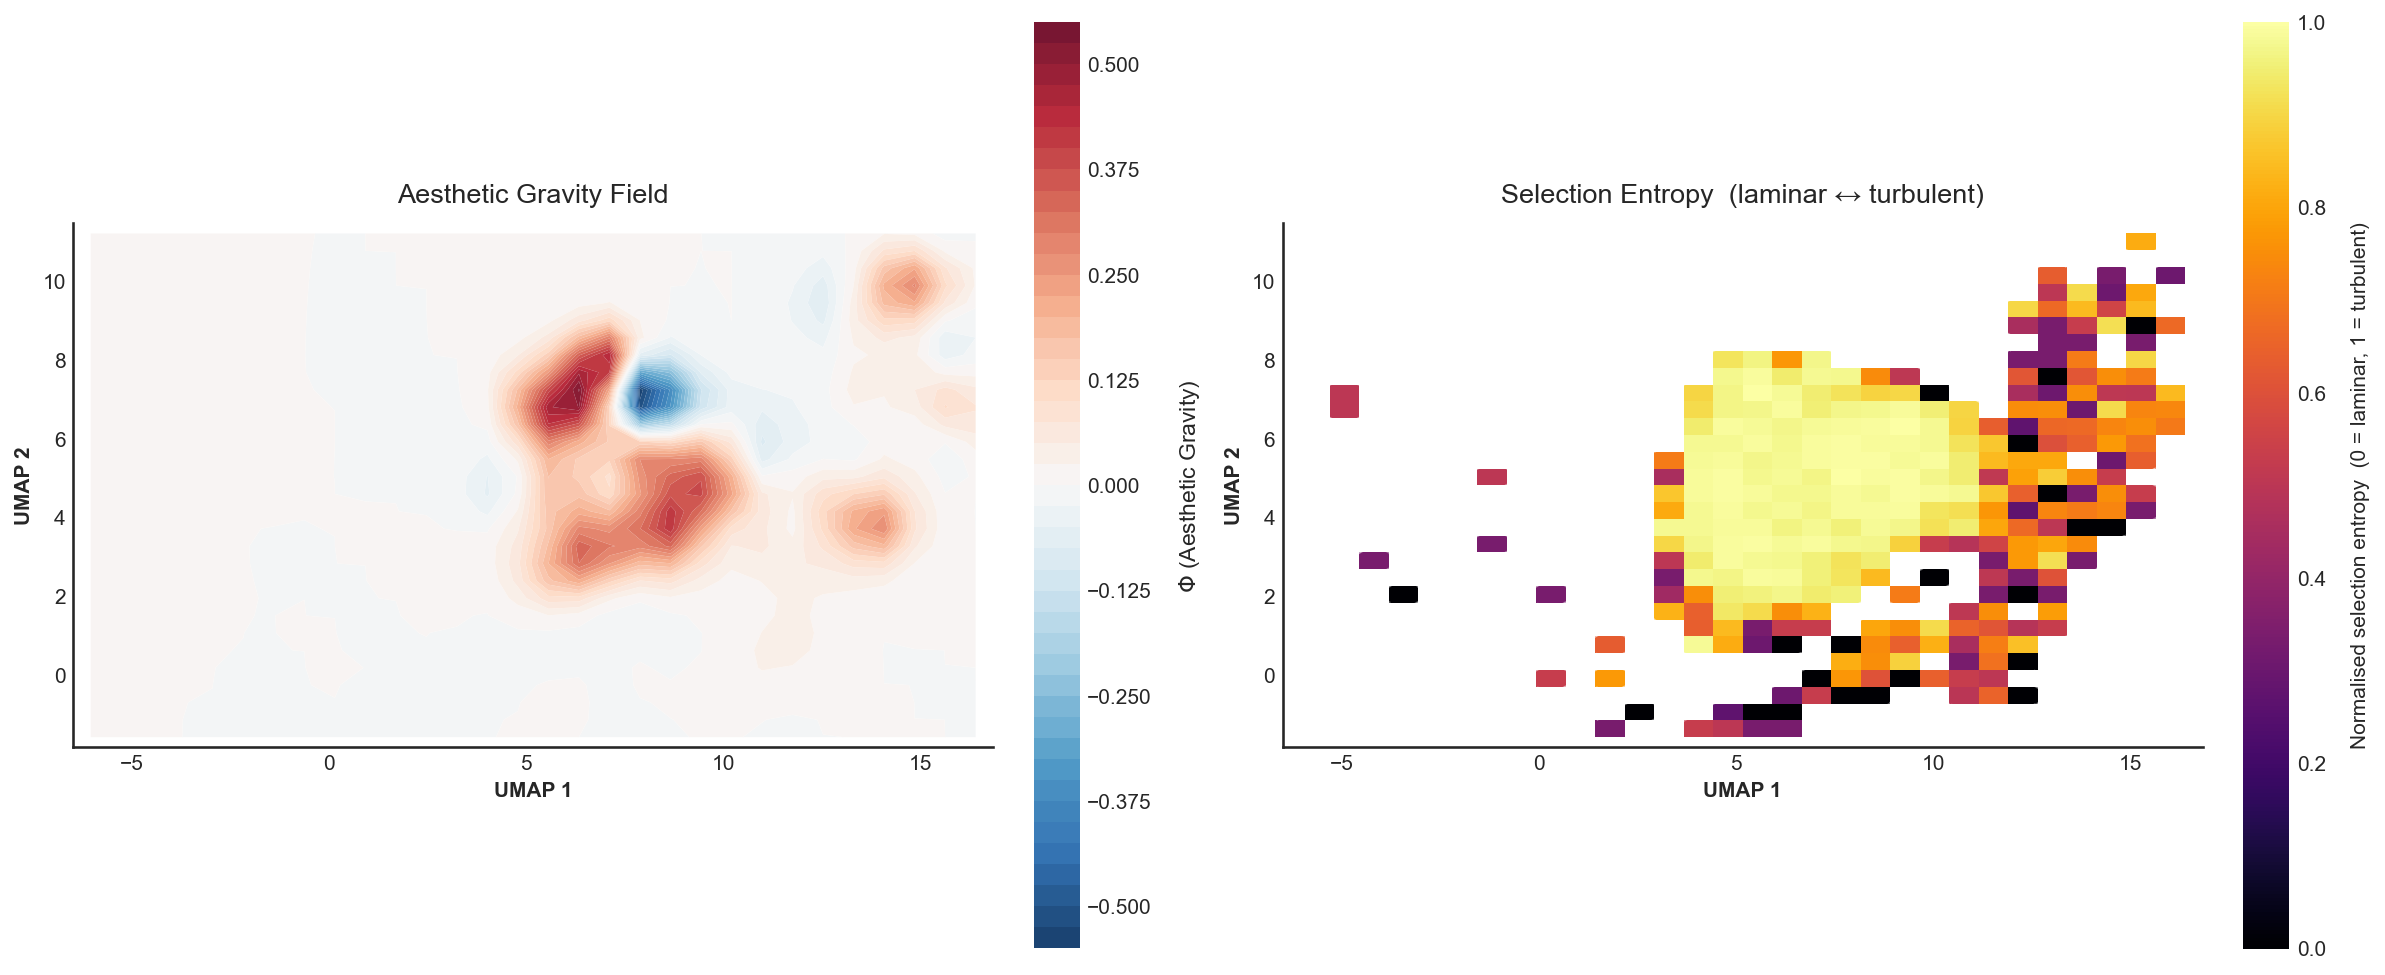

In [40]:
x_centres = 0.5 * (x_ent_edges[:-1] + x_ent_edges[1:])
y_centres = 0.5 * (y_ent_edges[:-1] + y_ent_edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

# ── Left: gravity field for reference ───────────────────────────────────────
ax = axes[0]
cf = ax.contourf(grid_x, grid_y, phi_1_2D, levels=50, cmap='RdBu_r', alpha=0.92, antialiased=True)
cb = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cb.outline.set_visible(False)
cb.set_label(r'$\Phi$ (Aesthetic Gravity)', fontsize=11, labelpad=12)
ax.set_title('Aesthetic Gravity Field', fontsize=13, pad=10)
ax.set_xlim(*UMAP_XLIM); ax.set_ylim(*UMAP_YLIM)
ax.set_aspect('equal')
ax.set_xlabel('UMAP 1', fontweight='bold'); ax.set_ylabel('UMAP 2', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# ── Right: selection entropy ─────────────────────────────────────────────────
ax = axes[1]
im = ax.pcolormesh(
    x_ent_edges, y_ent_edges, entropy_grid,
    cmap='inferno', vmin=0, vmax=1, shading='flat'
)
cb2 = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb2.outline.set_visible(False)
cb2.set_label('Normalised selection entropy  (0 = laminar, 1 = turbulent)', fontsize=10, labelpad=12)

# Contour the count so reader can see where data is sparse
ax.contour(x_centres, y_centres, count_grid,
           levels=[MIN_COUNT, 20, 50], colors='white', alpha=0.35,
           linewidths=[0.6, 0.9, 1.2], linestyles='--')

ax.set_title('Selection Entropy  (laminar ↔ turbulent)', fontsize=13, pad=10)
ax.set_xlim(*UMAP_XLIM); ax.set_ylim(*UMAP_YLIM)
ax.set_aspect('equal')
ax.set_xlabel('UMAP 1', fontweight='bold'); ax.set_ylabel('UMAP 2', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/selection_entropy_map.svg', dpi=300)
plt.show()


Data is not normally distributed (Shapiro-Wilk test p < 0.05). Spearman correlation may be more appropriate.
Gravity φ vs selection entropy  (n=309 cells)
  Pearson  r = +0.2742   p = 9.816e-07
  Spearman ρ = +0.3990   p = 3.112e-13

Interpretation:
  Positive correlation → high-gravity regions have higher entropy


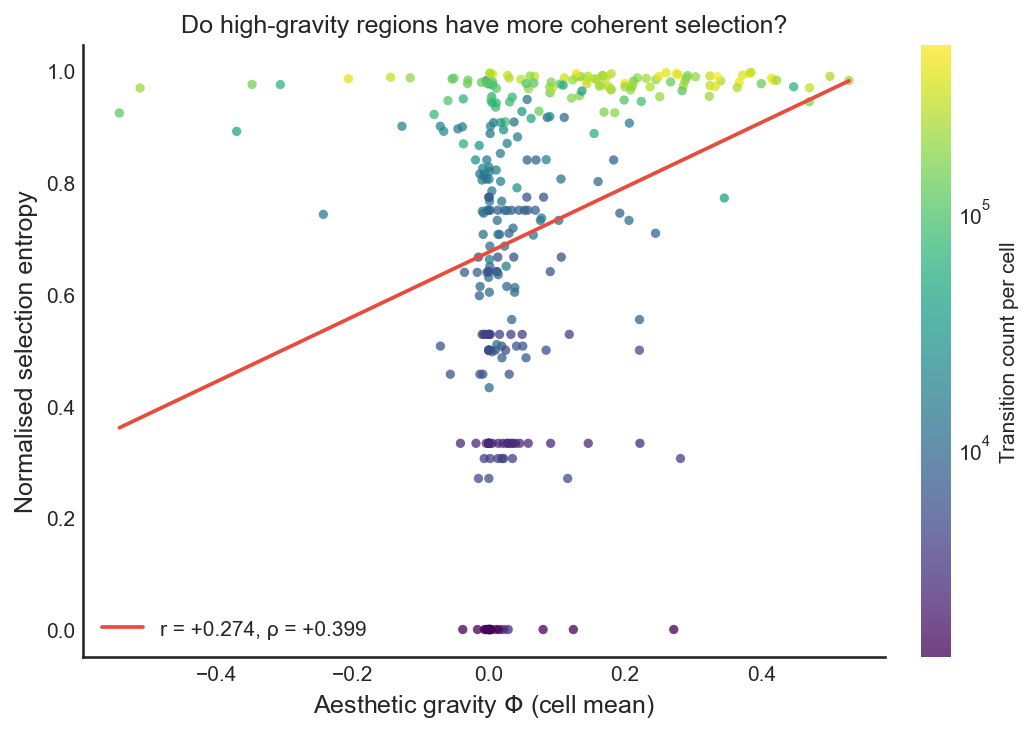

In [41]:
from scipy.stats import pearsonr, spearmanr, shapiro

# Flatten both grids, keep only cells that have entropy data
phi_flat     = phi_1_2D.ravel()
entropy_flat = entropy_grid.ravel()
count_flat   = count_grid.ravel()

valid = ~np.isnan(entropy_flat)
phi_v = phi_flat[valid]
ent_v = entropy_flat[valid]
cnt_v = count_flat[valid]

# Check normality of the data to decide whether Pearson or Spearman is more appropriate
_, p_phi = shapiro(phi_v)
_, p_ent = shapiro(ent_v)

if p_phi < 0.05 or p_ent < 0.05:
    print("Data is not normally distributed (Shapiro-Wilk test p < 0.05). Spearman correlation may be more appropriate.")
else:
    print("Data is approximately normally distributed (Shapiro-Wilk test p ≥ 0.05). Pearson correlation may be appropriate.")
r, p_r   = pearsonr(phi_v, ent_v)
rho, p_s = spearmanr(phi_v, ent_v)

print(f"Gravity φ vs selection entropy  (n={valid.sum()} cells)")
print(f"  Pearson  r = {r:+.4f}   p = {p_r:.3e}")
print(f"  Spearman ρ = {rho:+.4f}   p = {p_s:.3e}")
print()
print("Interpretation:")
print(f"  {'Negative' if r < 0 else 'Positive'} correlation → "
      f"{'high-gravity regions have lower entropy (more laminar — coherent pull toward attractor)' if r < 0 else 'high-gravity regions have higher entropy'}")

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sc = ax.scatter(phi_v, ent_v, c=cnt_v, cmap='viridis', s=20, alpha=0.75,
                linewidths=0, norm=plt.matplotlib.colors.LogNorm())
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.outline.set_visible(False)
cb.set_label('Transition count per cell', fontsize=10)

# Regression line
m, b = np.polyfit(phi_v, ent_v, 1)
xr = np.linspace(phi_v.min(), phi_v.max(), 100)
ax.plot(xr, m * xr + b, color='#e74c3c', linewidth=1.8, zorder=5,
        label=f'r = {r:+.3f}, ρ = {rho:+.3f}')

ax.set_xlabel(r'Aesthetic gravity $\Phi$ (cell mean)', fontsize=12)
ax.set_ylabel('Normalised selection entropy', fontsize=12)
ax.set_title('Do high-gravity regions have more coherent selection?', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/entropy_vs_gravity.svg', dpi=300)
plt.show()


In [42]:
OUTPUT_PATH = 'latent_space_game_with_gravity.parquet'

In [43]:
# gravity_no_flip / gravity_flip already computed in chunks in cell 0b8acb28;
# just pick the orientation that was selected rather than re-lifting the full df
gravity_scores = gravity_flip if pearson_flip > pearson_no_flip else gravity_no_flip


In [44]:
df['aesthetic_gravity'] = gravity_scores
trajectory_df = trajectory_df.merge(
    df[['vase_id', 'aesthetic_gravity']],
    on='vase_id',
    how='left'
)
print(df.shape)
df.head()

(1498500, 36)


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,source,generation_key,vase,...,session_started_at,session_duration_s,completion_status,umap_x,umap_y,generation,generation_num,parent_generation_num,parent_vase_id,aesthetic_gravity
0,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN,0.312309
1,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN,0.312309
2,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN,0.312309
3,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN,0.312309
4,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,1.778869e+09,119.029303,completed,9.628722,4.289236,gen_1,1,0,NaN,0.312309


In [45]:
df.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved dataframe with aesthetic gravity to: {OUTPUT_PATH}")
print(df[['vase_id', 'umap_x', 'umap_y', 'aesthetic_gravity']].head().to_string(index=False))

Saved dataframe with aesthetic gravity to: latent_space_game_with_gravity.parquet
                                                    vase_id   umap_x   umap_y  aesthetic_gravity
01553c98-79fa-475e-a939-772f9f3d5e18::round_0_gen_1::vase_1 9.628722 4.289236           0.312309
01553c98-79fa-475e-a939-772f9f3d5e18::round_0_gen_1::vase_1 9.628722 4.289236           0.312309
01553c98-79fa-475e-a939-772f9f3d5e18::round_0_gen_1::vase_1 9.628722 4.289236           0.312309
01553c98-79fa-475e-a939-772f9f3d5e18::round_0_gen_1::vase_1 9.628722 4.289236           0.312309
01553c98-79fa-475e-a939-772f9f3d5e18::round_0_gen_1::vase_1 9.628722 4.289236           0.312309


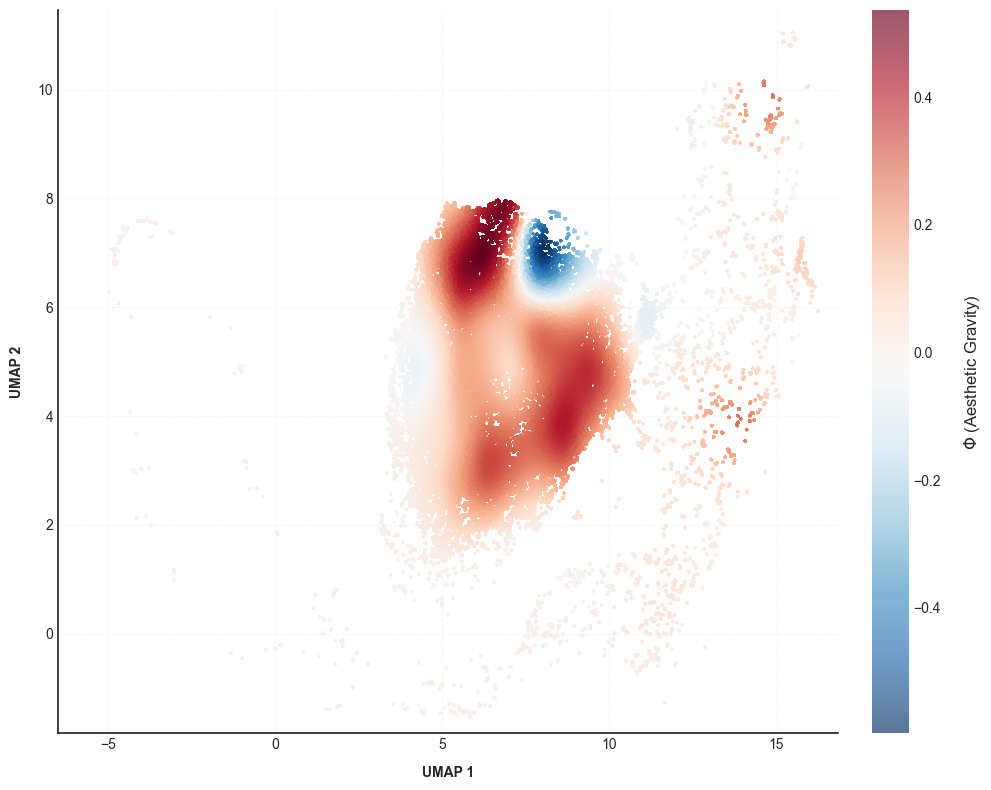

count    1.498500e+06
mean     1.727564e-01
std      1.711728e-01
min     -5.964471e-01
25%      6.213309e-02
50%      1.785539e-01
75%      2.990618e-01
max      5.365016e-01


In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    df['umap_x'],
    df['umap_y'],
    c=df['aesthetic_gravity'],
    cmap='RdBu_r',
    s=5,
    alpha=0.65,
    linewidths=0
)
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label(r'$\Phi$ (Aesthetic Gravity)', fontsize=12, labelpad=15)

ax.set_xlim(*UMAP_XLIM)
ax.set_ylim(*UMAP_YLIM)
ax.set_xlabel('UMAP 1', fontweight='bold', labelpad=10)
ax.set_ylabel('UMAP 2', fontweight='bold', labelpad=10)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', color='#EEEEEE', alpha=0.5)

plt.tight_layout()
plt.show()

print(df['aesthetic_gravity'].describe().to_string())

## 3. Plot Real Vases onto the UMAP Space Coloured by Beauty

In [52]:
GAME_XY_PATH = "../file_processing/processed/xy_data.parquet"

xy_df = pd.read_parquet(GAME_XY_PATH)
xy_df["vase_id"] = (
    xy_df["participant_id"].astype(str)
    + "::"
    + xy_df["generation_key"].astype(str)
    + "::"
    + xy_df["vase"].astype(str)
)
xy_df.head()

,generation_key,vase,x,y,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,vase_id
0,round_0_gen_1,vase_1,0.000650,1.977799,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
1,round_0_gen_1,vase_1,0.046236,1.977766,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
2,round_0_gen_1,vase_1,0.091811,1.977784,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
3,round_0_gen_1,vase_1,0.137535,1.977849,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
4,round_0_gen_1,vase_1,0.183402,1.978020,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...


In [53]:
OUTPUT_XY_PATH = 'aligned_master_game_xy_data_with_gravity.parquet'

required_cols = {'aesthetic_gravity', 'umap_x', 'umap_y'}
missing = required_cols.difference(df.columns)

if missing:
    raise RuntimeError(f"Missing columns: {sorted(missing)}")

In [54]:
vase_level_meta = (
    df[['vase_id', 'aesthetic_gravity', 'umap_x', 'umap_y']]
    .dropna(subset=['aesthetic_gravity', 'umap_x', 'umap_y'])
    .groupby('vase_id', as_index=False)
    .agg(
        aesthetic_gravity=('aesthetic_gravity', 'mean'),
        umap_x=('umap_x', 'mean'),
        umap_y=('umap_y', 'mean')
    )
)

In [55]:
remove_cols = [
    c for c in xy_df.columns
    if c in {'aesthetic_gravity', 'umap_x', 'umap_y'}
    or c.startswith('aesthetic_gravity_')
    or c.startswith('umap_x_')
    or c.startswith('umap_y_')
]
xy_base_df = xy_df.drop(columns=remove_cols, errors='ignore')

xy_base_df.head()

,generation_key,vase,x,y,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,vase_id
0,round_0_gen_1,vase_1,0.000650,1.977799,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
1,round_0_gen_1,vase_1,0.046236,1.977766,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
2,round_0_gen_1,vase_1,0.091811,1.977784,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
3,round_0_gen_1,vase_1,0.137535,1.977849,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
4,round_0_gen_1,vase_1,0.183402,1.978020,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...


In [56]:
xy_with_meta_df = xy_base_df.merge(
    vase_level_meta,
    on='vase_id',
    how='left',
    validate='many_to_one'
)

xy_df = xy_with_meta_df

xy_df.head()

,generation_key,vase,x,y,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,vase_id,aesthetic_gravity,umap_x,umap_y
0,round_0_gen_1,vase_1,0.000650,1.977799,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.312309,9.628722,4.289236
1,round_0_gen_1,vase_1,0.046236,1.977766,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.312309,9.628722,4.289236
2,round_0_gen_1,vase_1,0.091811,1.977784,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.312309,9.628722,4.289236
3,round_0_gen_1,vase_1,0.137535,1.977849,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.312309,9.628722,4.289236
4,round_0_gen_1,vase_1,0.183402,1.978020,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.312309,9.628722,4.289236


In [57]:
xy_df.to_parquet(OUTPUT_XY_PATH, index=False)

print(f"Saved XY dataframe with gravity + UMAP to: {OUTPUT_XY_PATH}")

Saved XY dataframe with gravity + UMAP to: aligned_master_game_xy_data_with_gravity.parquet


In [59]:
matched = xy_df['aesthetic_gravity'].notna().sum()
matched_umap = (xy_df['umap_x'].notna() & xy_df['umap_y'].notna()).sum()
total = len(xy_df)

print(f"Matched gravity rows: {matched:,} / {total:,} ({matched / total:.1%})")
print(f"Matched UMAP rows: {matched_umap:,} / {total:,} ({matched_umap / total:.1%})")
xy_df[['vase_id', 'x', 'y', 'umap_x', 'umap_y', 'aesthetic_gravity']].head()

Matched gravity rows: 12,487,500 / 12,487,500 (100.0%)
Matched UMAP rows: 12,487,500 / 12,487,500 (100.0%)


,vase_id,x,y,umap_x,umap_y,aesthetic_gravity
0,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.000650,1.977799,9.628722,4.289236,0.312309
1,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.046236,1.977766,9.628722,4.289236,0.312309
2,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.091811,1.977784,9.628722,4.289236,0.312309
3,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.137535,1.977849,9.628722,4.289236,0.312309
4,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.183402,1.978020,9.628722,4.289236,0.312309


In [60]:
SEQUENCE_LENGTH = 250

In [61]:
def normalize_to_range(arr, lo=-1.0, hi=1.0):
    a_min, a_max = np.min(arr), np.max(arr)
    if a_max - a_min < 1e-9:
        return np.zeros_like(arr, dtype=np.float32)
    return ((arr - a_min) / (a_max - a_min) * (hi - lo) + lo).astype(np.float32)

In [62]:
# Build normalised contours from xy_df directly (keyed by vase_id).
contours_by_vase = {}
for vase_id, grp in xy_df.groupby('vase_id', sort=False):
    if 'coord_order' in grp.columns:
        grp = grp.sort_values('coord_order')
    x = grp['x'].to_numpy(dtype=float)
    y = grp['y'].to_numpy(dtype=float)
    if len(x) < 3:
        continue
    if x[0] != x[-1] or y[0] != y[-1]:
        x = np.append(x, x[0])
        y = np.append(y, y[0])
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    scale = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)), 1e-9)
    contours_by_vase[str(vase_id)] = np.vstack([x / scale, y / scale])
print(f"Built {len(contours_by_vase)} normalised contours from xy_df")

Built 49950 normalised contours from xy_df


In [63]:
GRID_SIZE = 100

In [64]:
# Build one UMAP/gravity record per vase so selection indices align with contour indices.
vase_meta = (
    xy_df.groupby('vase_id', as_index=False)
    .agg(
        umap_x=('umap_x', 'mean'),
        umap_y=('umap_y', 'mean'),
        aesthetic_gravity=('aesthetic_gravity', 'mean')
    )
)
vase_meta.head()

,vase_id,umap_x,umap_y,aesthetic_gravity
0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,4.898610,4.559932,0.028330
1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,7.006062,1.829477,0.018917
2,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,7.000542,1.829155,0.019193
3,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,5.810210,3.463166,0.220625
4,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,6.998490,1.826839,0.019008


In [65]:
print(f"vase_meta: {len(vase_meta):,} rows — used for gravity score lookup and background scatter")

vase_meta: 49,950 rows — used for gravity score lookup and background scatter


In [66]:
x_min, x_max = UMAP_X_MIN, UMAP_X_MAX
y_min, y_max = UMAP_Y_MIN, UMAP_Y_MAX
pad_x = (x_max - x_min) * 0.02
pad_y = (y_max - y_min) * 0.02
x_edges = np.linspace(x_min - pad_x, x_max + pad_x, GRID_SIZE + 1)
y_edges = np.linspace(y_min - pad_y, y_max + pad_y, GRID_SIZE + 1)

xs = vase_meta['umap_x'].to_numpy()
ys = vase_meta['umap_y'].to_numpy()
ix = np.clip(np.searchsorted(x_edges, xs) - 1, 0, GRID_SIZE - 1)
iy = np.clip(np.searchsorted(y_edges, ys) - 1, 0, GRID_SIZE - 1)

In [67]:
# For each occupied grid cell, pick the vase whose UMAP position is closest to the cell centre.
# ix, iy, xs, ys come from the grid assignment above.
chosen = {}
for i in range(len(vase_meta)):
    cx_i, cy_i = int(ix[i]), int(iy[i])
    key = (cx_i, cy_i)
    cx = 0.5 * (x_edges[cx_i] + x_edges[cx_i + 1])
    cy = 0.5 * (y_edges[cy_i] + y_edges[cy_i + 1])
    d = (xs[i] - cx) ** 2 + (ys[i] - cy) ** 2
    if key not in chosen or d < chosen[key][2]:
        chosen[key] = (vase_meta.iloc[i]['vase_id'], 'game', d)
print(f"Assigned {len(chosen)} grid cells to nearest vase")

Assigned 2085 grid cells to nearest vase


In [68]:
fig, ax = plt.subplots(figsize=(14, 14), dpi=600)
ax.scatter(xs, ys, s=6, color='lightgrey', alpha=0.25, zorder=1)

cell_w = x_edges[1] - x_edges[0]
cell_h = y_edges[1] - y_edges[0]
draw_scale = min(cell_w, cell_h) * 0.45

gravity_by_vase = vase_meta.set_index('vase_id')['aesthetic_gravity'].to_dict()
gmin = vase_meta['aesthetic_gravity'].min()
gmax = vase_meta['aesthetic_gravity'].max()

norm = plt.Normalize(vmin=gmin, vmax=gmax)
cmap = plt.cm.RdBu_r

for (cx_i, cy_i), (vase_id, source, _) in chosen.items():
    cx = 0.5 * (x_edges[cx_i] + x_edges[cx_i + 1])
    cy = 0.5 * (y_edges[cy_i] + y_edges[cy_i + 1])

    contour = contours_by_vase.get(str(vase_id))
    if contour is None:
        continue

    gx = cx + contour[0] * draw_scale
    gy = cy + contour[1] * draw_scale

    gravity = gravity_by_vase.get(vase_id, np.nan)
    colour = (0.7, 0.7, 0.7, 0.35) if pd.isna(gravity) else cmap(norm(gravity))

    ax.fill(
        gx, gy,
        facecolor=colour,
        edgecolor="#00000000",
        alpha=0.9,
        linewidth=0.2,
        zorder=2
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label(r'$\Phi$ (Aesthetic Gravity)', fontsize=12, labelpad=15)

ax.set_aspect('equal')
ax.set_xlim(*UMAP_XLIM)
ax.set_ylim(*UMAP_YLIM)
ax.set_xlabel('UMAP 1', fontweight='bold', labelpad=10)
ax.set_ylabel('UMAP 2', fontweight='bold', labelpad=10)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', color='#EEEEEE', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/vase_contours_gravity_map.svg', dpi=600)
plt.show()

## 4. Identify the Most Beautiful Vases

In [69]:
import pandas as pd
import os

In [91]:
REAL_VASES_PATH = "umap_projections/real_vase_umap_projection.parquet"

real_vases_df = pd.read_parquet(REAL_VASES_PATH)
real_vases_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,generation_key,pc_name,...,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,metadata_schema_version,session_started_at,session_duration_s,completion_status,umap_x,umap_y
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,None,None,...,NaN,NaN,None,None,NaN,NaN,NaN,None,10.381421,0.831381
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,None,None,...,NaN,NaN,None,None,NaN,NaN,NaN,None,12.256351,0.586361
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,None,None,...,NaN,NaN,None,None,NaN,NaN,NaN,None,11.624378,5.914351
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,None,None,...,NaN,NaN,None,None,NaN,NaN,NaN,None,12.032199,5.516442
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,None,None,...,NaN,NaN,None,None,NaN,NaN,NaN,None,3.008078,-0.721337


In [92]:
# Map real_vases_df onto the gravity field and compute aesthetic gravity for each vase.
required_cols = {"umap_x", "umap_y"}
missing_cols = required_cols - set(real_vases_df.columns)
if missing_cols:
    raise ValueError(f"real_vases_df is missing required columns: {sorted(missing_cols)}")

In [93]:
real_vase_points = np.vstack([
    real_vases_df["umap_x"].to_numpy(),
    real_vases_df["umap_y"].to_numpy(),
])  # (2, N)

n_real = real_vase_points.shape[1]
real_gravity = np.empty(n_real)
for start in range(0, n_real, CHUNK_SIZE):
    sl = slice(start, start + CHUNK_SIZE)
    psi_chunk = lift_to_observables(real_vase_points[:, sl], centres, SIGMA)
    real_gravity[sl] = (dominant_eigenvector @ psi_chunk).real

real_vases_df = real_vases_df.copy()
real_vases_df["aesthetic_gravity"] = real_gravity

real_vases_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,generation_key,pc_name,...,rt_calibration_trials_n,participant_id,session_id,metadata_schema_version,session_started_at,session_duration_s,completion_status,umap_x,umap_y,aesthetic_gravity
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,None,None,...,NaN,None,None,NaN,NaN,NaN,None,10.381421,0.831381,0.012824
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,None,None,...,NaN,None,None,NaN,NaN,NaN,None,12.256351,0.586361,0.023597
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,None,None,...,NaN,None,None,NaN,NaN,NaN,None,11.624378,5.914351,-0.046932
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,None,None,...,NaN,None,None,NaN,NaN,NaN,None,12.032199,5.516442,-0.007738
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,None,None,...,NaN,None,None,NaN,NaN,NaN,None,3.008078,-0.721337,-0.000071


In [94]:
LATENT_SAVE_DIR = "gravity_projections"
os.makedirs(LATENT_SAVE_DIR, exist_ok=True)

In [96]:
real_vases_df = real_vases_df[['vase_id', 'umap_x', 'umap_y', 'aesthetic_gravity', 'culture_general',]]
real_vases_df.head()

,vase_id,umap_x,umap_y,aesthetic_gravity,culture_general
0,af_1,10.381421,0.831381,0.012824,african_subsaharan
1,af_10,12.256351,0.586361,0.023597,african_subsaharan
2,af_101,11.624378,5.914351,-0.046932,african_subsaharan
3,af_102,12.032199,5.516442,-0.007738,african_subsaharan
4,af_103,3.008078,-0.721337,-0.000071,african_subsaharan


In [97]:
REAL_LATENT_SAVE_PATH = "real_vase_umap_gravity.parquet"
real_vases_df.to_parquet(os.path.join(LATENT_SAVE_DIR, REAL_LATENT_SAVE_PATH), index=False)

In [98]:
REAL_VASES_XY_PATH = "../real_vase_data/all_profiles_120526.parquet"
real_vases_xy_df = pd.read_parquet(REAL_VASES_XY_PATH)
real_vases_xy_df.head()

,gpp_no,x,y,point_order
0,amph_1002176,-0.012187,1.5,0
1,amph_1002176,0.025235,1.5,1
2,amph_1002176,0.062658,1.5,2
3,amph_1002176,0.100081,1.5,3
4,amph_1002176,0.137504,1.5,4


In [101]:
meta_cols = ['vase_id', 'umap_x', 'umap_y', 'aesthetic_gravity',
             'culture_general',
             ]

real_vases_xy_df.rename(columns={'gpp_no': 'vase_id'}, inplace=True)  # ensure 'vase_id' column exists for merging

real_vases_xy_df = real_vases_xy_df.merge(
    real_vases_df[meta_cols],
    on='vase_id',
    how='left',
    validate='many_to_one'
)
real_vases_xy_df.head()

,vase_id,x,y,point_order,umap_x,umap_y,aesthetic_gravity,culture_general
0,amph_1002176,-0.012187,1.5,0,13.905229,5.14839,0.051935,european
1,amph_1002176,0.025235,1.5,1,13.905229,5.14839,0.051935,european
2,amph_1002176,0.062658,1.5,2,13.905229,5.14839,0.051935,european
3,amph_1002176,0.100081,1.5,3,13.905229,5.14839,0.051935,european
4,amph_1002176,0.137504,1.5,4,13.905229,5.14839,0.051935,european


In [102]:
REAL_XY_SAVE_PATH = "real_vase_xy_gravity.parquet"
real_vases_df.to_parquet(os.path.join(LATENT_SAVE_DIR, REAL_XY_SAVE_PATH), index=False)

In [103]:
most_beautiful_vase = real_vases_df.loc[real_vases_df['aesthetic_gravity'].idxmax()]
most_beautiful_vase_df = real_vases_xy_df[real_vases_xy_df['vase_id'] == most_beautiful_vase['vase_id']].copy()
print(most_beautiful_vase_df.shape)
most_beautiful_vase_df.head()

(250, 8)


,vase_id,x,y,point_order,umap_x,umap_y,aesthetic_gravity,culture_general
14167250,met_255327,-0.022303,1.264769,0,5.960683,6.778965,0.519022,european
14167251,met_255327,0.023243,1.264769,1,5.960683,6.778965,0.519022,european
14167252,met_255327,0.068790,1.264769,2,5.960683,6.778965,0.519022,european
14167253,met_255327,0.114336,1.264769,3,5.960683,6.778965,0.519022,european
14167254,met_255327,0.159883,1.264769,4,5.960683,6.778965,0.519022,european


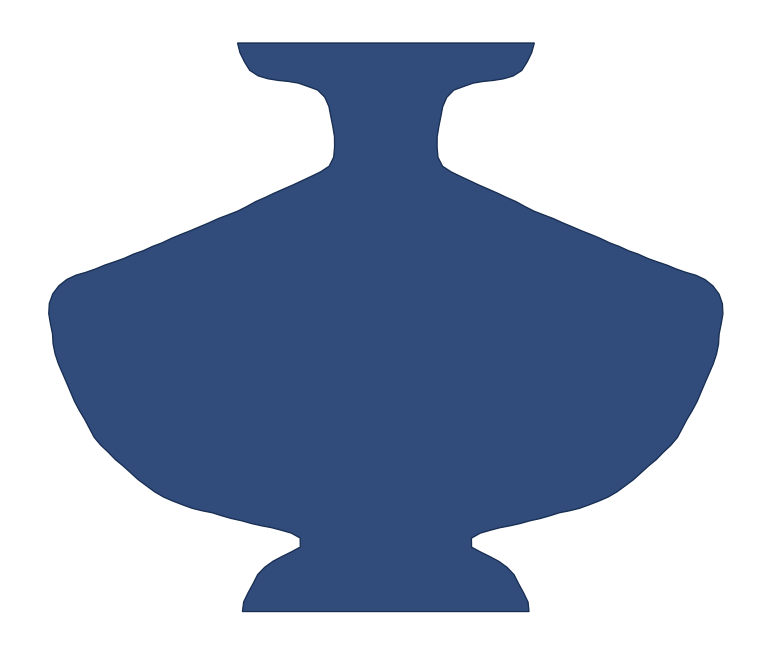

In [105]:
x = most_beautiful_vase_df['x'].to_numpy()
y = most_beautiful_vase_df['y'].to_numpy()

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
ax.fill(x, y, facecolor='#1f3b70', edgecolor='#0d2448', linewidth=0.6, alpha=0.92)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout(pad=0.2)
plt.show()
